<img align="left" src = https://project.lsst.org/sites/default/files/Rubin-O-Logo_0.png width=250 style="padding: 10px"> 
<br>
<b>Prompt processing analysis (03/02/2026)</b> <br>
Contact author: Bruno Sanchez<br>
Last verified to run: 03 February 2026<br>
LSST Science Piplines version: w_2026_04<br>
Run at USDF on repo embargo

# 1. Main package imports

In [1]:
import os
import importlib
import pprint

import matplotlib.pyplot as plt
%matplotlib inline

import math
import numpy as np
import pandas as pd
import scipy
import astropy.units as u
from astropy.coordinates import SkyCoord

In [2]:
np.set_printoptions(precision=3)

In [3]:
import lsst.afw.image as afwImage
import lsst.afw.display as afwDisplay
import lsst.geom
import lsst.afw.geom as afwGeom

import lsst.daf.butler as dafButler
import lsst.pipe.base

In [4]:
from lsst.analysis.ap import apdb
from lsst.analysis.ap import nb_utils
from astropy.table import Table, hstack, vstack

In [5]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

In [6]:
afwDisplay.setDefaultBackend("matplotlib")

## Load previous run datasheets

In [7]:
import os
os.chdir('./u/DM-53803')

FileNotFoundError: [Errno 2] No such file or directory: './u/DM-53803'

In [60]:
daytime_run = pd.read_csv('daytime_rerun_processingIds.csv')

In [61]:
prompt_run = pd.read_csv('prompt_rerun_processingIds.csv')

In [62]:
prompt_run

,Unnamed: 0,instrument,detector,visit,band,day_obs,physical_filter,computeReliability:computeReliability:__version__,computeReliability:computeReliability:nodeName,computeReliability:computeReliability:runStartUtc,...,computeReliability:computeReliability:deltaTimeCpuTime,computeReliability:computeReliability:deltaTimeUserTime,computeReliability:computeReliability:deltaTimeSystemTime,collection,date,computeReliability:quantum:butler_metrics:time_in_ingest,computeReliability:quantum:butler_metrics:n_ingest,quantum:quantum:butler_metrics:time_in_ingest,quantum:quantum:butler_metrics:n_ingest,n_chunks
0,11,LSSTCam,112,2026012800097,g,20260128,g_6,1.0,prompt-keda-lsstcam-mpjgw-ljvnt,2026-01-29T01:53:24.008610+00:00,...,9.755554,8.569421,1.185831,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,1.0
1,26,LSSTCam,50,2026012800097,g,20260128,g_6,1.0,prompt-keda-lsstcam-bwwf5-x26s6,2026-01-29T01:53:15.834037+00:00,...,9.815232,8.645919,1.169100,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,1.0
2,46,LSSTCam,46,2026012800092,g,20260128,g_6,1.0,prompt-keda-lsstcam-c5km5-5gg8c,2026-01-29T01:45:02.211604+00:00,...,9.825626,8.693069,1.132378,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,1.0
3,135,LSSTCam,96,2026012800092,g,20260128,g_6,1.0,prompt-keda-lsstcam-5twnt-bp8xc,2026-01-29T01:45:14.388277+00:00,...,10.100236,8.811662,1.288367,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,1.0
4,161,LSSTCam,112,2026012800092,g,20260128,g_6,1.0,prompt-keda-lsstcam-s5b4m-zs7kk,2026-01-29T01:45:18.805796+00:00,...,9.895243,8.778126,1.116730,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,1448,LSSTCam,96,2026012800099,i,20260128,i_39,1.0,prompt-keda-lsstcam-p4tvk-67pb4,2026-01-29T01:58:23.356119+00:00,...,15.045140,13.478250,1.566692,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,2.0
76,1452,LSSTCam,129,2026012800099,i,20260128,i_39,1.0,prompt-keda-lsstcam-xvv5g-76mtg,2026-01-29T01:58:18.149313+00:00,...,14.417597,12.809920,1.607513,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,2.0
77,1461,LSSTCam,50,2026012800099,i,20260128,i_39,1.0,prompt-keda-lsstcam-fsc6p-8nhjp,2026-01-29T01:58:19.518958+00:00,...,15.208513,13.654964,1.553429,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,2.0
78,1499,LSSTCam,57,2026012800099,i,20260128,i_39,1.0,prompt-keda-lsstcam-d42wb-sk257,2026-01-29T01:58:37.638176+00:00,...,14.880731,13.138375,1.742266,LSSTCam/prompt/output-2026-01-28/ApPipe-noForc...,2026-01-28,0.0,0.0,0.0,0.0,2.0


### Some functions for loading and processing

In [8]:
from copy import copy
from lsst.pipe.base._task_metadata import TaskMetadata

def unpack_nested_dict(d, parent_key='', result=None):
    if result is None:
        result = {}
    if not isinstance(d, (dict, TaskMetadata)): 
        new_key = f"{parent_key}" if parent_key else 'sValue'
        result[new_key] = d
        return result
    for key, value in d.items():
        # Create a new key path
        new_key = f"{parent_key}:{key}" if parent_key else key

        if isinstance(value, (dict, TaskMetadata)) :
            # Recursive call to process nested dictionaries
            unpack_nested_dict(dict(value), new_key, result)
        else:
            # Store the concatenated key path and value in the result dictionary
            result[new_key] = value[0] if isinstance(value, list) else value

    return result

In [9]:
def get_delta_proc_times(df, basekey):
    time_colnames = ['Utc', 'CpuTime', 'UserTime', 'SystemTime']
    df_new = df.copy()

    for atime in time_colnames:
        if atime == 'Utc':
            start_time = pd.to_datetime(df[basekey+':runStart'+atime])
            end_time = pd.to_datetime(df[basekey+':runEnd'+atime])
            delta_time = end_time - start_time
            df_new[basekey+':runStart'+atime+'_dt'] = start_time
            df_new[basekey+':runEnd'+atime+'_dt'] = end_time
            df_new[basekey+':deltaTime'+atime+'_dt'] = delta_time
            df_new[basekey+':deltaTime'+atime+'_dt_secs'] = delta_time.dt.total_seconds()
        else:
            start_time = df[basekey+':runStart'+atime]
            end_time = df[basekey+':runEnd'+atime]
            df_new[basekey+':deltaTime'+atime] = end_time - start_time
    
    return df_new

In [10]:
def count_diaSources(visit, detector):
    """Count diaSources and compute mean reliability for a given visit and detector."""
    try:
        candidate = butler.get("dia_source_detector", visit=visit, detector=detector)
        # standard = butler.get("dia_source_detector", visit=visit, detector=detector)
        # dia_source = butler.get("dia_source_apdb", visit=visit, detector=detector)
        # print(f"{visit}: {len(candidate)} | {len(dia_source)}")
        return visit, detector, len(candidate), np.mean(candidate['reliability']),  #len(dia_source), np.mean(dia_source['reliability'])
    except dafButler.DatasetNotFoundError:
        return visit, detector, np.nan, np.nan, # np.nan, np.nan
        # print(f"{visit} detector {detector} not found")

In [11]:
def dump_logs_to_file(metadata_df, butler, filename='logs_plain_text.log', task='computeReliability'):
    with open(filename, 'w') as f:
        for rowid, rowdata in metadata_df.iterrows():
            row_log = butler.get(f'{task}_log', visit=rowdata['visit'], detector=rowdata['detector'])
            for log in row_log:
                f.write(log.message + '\n')
    return filename

In [12]:
def load_timings_from_logs(meta_df_2, butler):
    nsrcs = np.zeros(len(meta_df_2), dtype=int)
    tmplt_read_timing = np.zeros(len(meta_df_2), dtype=float)
    science_read_timing = np.zeros(len(meta_df_2), dtype=float)
    diff_read_timing = np.zeros(len(meta_df_2), dtype=float)
    for rowid, rowdata in meta_df_2.iterrows():
        # print(rowid)
        # print(rowdata['visit'], rowdata['detector'])
        row_log = butler.get('computeReliability_log', visit=rowdata['visit'], detector=rowdata['detector'])
        for log in row_log:
            if 'Scored' in log.message:
                n_stamps = int(log.message.split()[1])
            if 'Reading from location' in log.message and 'FitsExposureFormatter' in log.message:
                # reading data in image format
                if 'template_detector' in log.message:
                    # reading template
                    tmplt_read_time = float(log.message.split()[-2])
                    tmplt_read_timing[rowid] = tmplt_read_time
                if 'preliminary_visit_image' in log.message:
                    # reading science image
                    science_read_time = float(log.message.split()[-2])
                    science_read_timing[rowid] = science_read_time
                if 'difference_image' in log.message:
                    # reading difference image
                    diff_read_time = float(log.message.split()[-2])
                    diff_read_timing[rowid] = diff_read_time

        nsrcs[rowid] = n_stamps
        
    meta_df_2['n_stamps_scored'] = nsrcs
    meta_df_2['tmplt_read_timing'] = tmplt_read_timing
    meta_df_2['science_read_timing'] = science_read_timing
    meta_df_2['diff_read_timing'] = diff_read_timing

    return meta_df_2

In [13]:
def load_meta_and_logs(drefs, butler=butler):
    datarows = []
    for aref in drefs:
        datarow = dict(aref.dataId.to_simple())['dataId']
        try:
            rb_meta = butler.get(aref)
            for kmetric, vmetric in rb_meta.items():
                datarow.update(unpack_nested_dict(rb_meta, parent_key=kmetric))
            rb_log = butler.get('computeReliability_log', dataId=aref.dataId)
            for aline in rb_log:
                if 'Scored ' in aline.message:
                    n_stamps = int(aline.message.split()[1])
                    break
            datarow['n_stamps_scored'] = n_stamps
            datarows.append(datarow)
        except:
            continue
    metadata_df = pd.DataFrame(datarows)
    return metadata_df

NameError: name 'butler' is not defined

In [14]:
def parse_prompt_collection(collection_name):
    butler = dafButler.Butler('/repo/embargo', instrument='LSSTCam', collections=collection_name)
    drefs = butler.registry.queryDatasets("computeReliability_metadata", collections=collection_name)
    print("Amount of data refs in the collection for dia_source_detector:", len(list(drefs)))
    meta_df = load_meta_and_logs(drefs, butler=butler)
    meta_df = get_delta_proc_times(meta_df, 'computeReliability:computeReliability')
    return meta_df

# Get a butler

We will grabbing data from the 

In [15]:
repo = 's3://rubin-pp-dev-users/central_repo_2'

In [19]:
skymap = "lsst_cells_v2"
butler = dafButler.Butler(repo, instrument='LSSTCam', skymap='lsst_cells_v2')
skyMap = butler.get("skyMap", collections="skymaps", skymap="lsst_cells_v2")

In [20]:
def find_datasets(butler, dataset, collectionPattern="*"):
    infos = {}
    for info in butler.collections.query_info(collectionPattern, include_summary=True):
        if dataset in info.dataset_types:
            print(info.name)
            infos[info.name] = info
    return infos

In [21]:
camera = butler.get("camera", instrument='LSSTCam', collections=["LSSTCam/calib", "LSSTCam/defaults"] )

In [23]:
infos = find_datasets(butler, "difference_image", 
                      collectionPattern="LSSTCam/prompt/output-2026-04-02/ApPipe/pipelines-158cbe2-config-0dc223f*") #/prompt*")

LSSTCam/prompt/output-2026-04-02/ApPipe/pipelines-158cbe2-config-0dc223f


In [24]:
# infoprompt = infos['LSSTCam/prompt/output-2026-02-09/ApPipe/pipelines-c82627e-config-0dc223f']
infoprompt = infos['LSSTCam/prompt/output-2026-04-02/ApPipe/pipelines-158cbe2-config-0dc223f']

In [25]:
# date = "2026-01-27"  # example date of the prompt processing
# collection_base = "LSSTCam/prompt/output-"+date
collection_base = 'LSSTCam/prompt/output-2026-04-02/ApPipe/pipelines-158cbe2-config-0dc223f'
butler.registry.queryCollections(collection_base)

['LSSTCam/prompt/output-2026-04-02/ApPipe/pipelines-158cbe2-config-0dc223f']

In [26]:
butler = dafButler.Butler(
    repo, instrument='LSSTCam', skymap='lsst_cells_v1', collections=collection_base
)

In [27]:
drefs = butler.registry.queryDatasets(
    "computeReliability_metadata", 
    collections=collection_base
)

In [28]:
print("Amount of data refs in the collection for dia_source_detector:", len(list(drefs)))

Amount of data refs in the collection for dia_source_detector: 3800


In [29]:
visits = []
detectors = []
bands = []
for ref in drefs:
    dataId = ref.dataId
    visits.append(dataId['visit'])
    detectors.append(dataId['detector'])
    bands.append(dataId['band'])
visits = set(visits)
detectors = set(detectors)
bands = set(bands)

In [30]:
# Show up how many visits and unique detectors and bands are present
print(len(visits), len(detectors), len(bands))
print(visits, bands)

21 188 2
{2026040220001, 2026040220002, 2026040220003, 2026040220004, 2026040220005, 2026040220006, 2026040220007, 2026040220008, 2026040220009, 2026040220010, 2026040220011, 2026040220012, 2026040220013, 2026040220014, 2026040220015, 2026040220016, 2026040220017, 2026040220018, 2026040220019, 2026040220020, 2026040220021} {'i', 'g'}


In [31]:
ref

DatasetRef(DatasetType('computeReliability_metadata', {band, instrument, day_obs, detector, physical_filter, visit}, TaskMetadata), {instrument: 'LSSTCam', detector: 147, visit: 2026040220021, band: 'i', day_obs: 20260402, physical_filter: 'i_39'}, run='LSSTCam/prompt/output-2026-04-02/ApPipe/pipelines-158cbe2-config-0dc223f', id=019d4f70-b6bf-787a-9ab3-5bb5b28dc8c2)

In [32]:
ref.dataId

{instrument: 'LSSTCam', detector: 147, visit: 2026040220021, band: 'i', day_obs: 20260402, physical_filter: 'i_39'}

In [33]:
datarows = []
for aref in drefs:
    datarow = dict(aref.dataId.to_simple())['dataId']
    try:
        rb_meta = butler.get(aref)
        for kmetric, vmetric in rb_meta.items():
            datarow.update(unpack_nested_dict(rb_meta, parent_key=kmetric))
        datarows.append(datarow)
    except:
        continue
metadata_df = pd.DataFrame(datarows)

In [34]:
metadata_df

,instrument,detector,visit,band,day_obs,physical_filter,computeReliability:computeReliability:__version__,computeReliability:computeReliability:nodeName,computeReliability:computeReliability:runStartUtc,computeReliability:computeReliability:runStartCpuTime,...,quantum:quantum:endBlockOutputs,quantum:quantum:endVoluntaryContextSwitches,quantum:quantum:endInvoluntaryContextSwitches,quantum:quantum:outputs,quantum:quantum:butler_metrics:time_in_put,quantum:quantum:butler_metrics:time_in_get,quantum:quantum:butler_metrics:time_in_ingest,quantum:quantum:butler_metrics:n_get,quantum:quantum:butler_metrics:n_put,quantum:quantum:butler_metrics:n_ingest
0,LSSTCam,33,2026040220006,g,20260402,g_6,1,prompt-keda-lsstcam-wd6mv-zl2sl,2026-04-02T17:53:45.370844+00:00,112.149190,...,3320608,34560,1475,019d4f52-f1c8-7b08-8cad-cad5680851f5,0.009149,3.969834,0.0,5,1,0
1,LSSTCam,29,2026040220003,g,20260402,g_6,1,prompt-keda-lsstcam-th9nn-zzwd7,2026-04-02T17:53:36.270218+00:00,168.977520,...,5533552,70806,3251,019d4f51-6216-7ce5-8e0e-02ffe8972799,0.010112,5.272774,0.0,5,1,0
2,LSSTCam,114,2026040220004,g,20260402,g_6,1,prompt-keda-lsstcam-xvdwf-k9g4c,2026-04-02T17:53:41.629727+00:00,371.274517,...,6207680,166326,6931,019d4f51-dc50-739a-a265-1fceb2789f34,0.009725,4.523016,0.0,5,1,0
3,LSSTCam,5,2026040220005,g,20260402,g_6,1,prompt-keda-lsstcam-qrcbd-cr6r5,2026-04-02T17:53:48.480247+00:00,172.380657,...,3758440,89871,2716,019d4f52-4f3a-7432-98d9-a4961624b539,0.009635,5.374025,0.0,5,1,0
4,LSSTCam,179,2026040220001,g,20260402,g_6,1,prompt-keda-lsstcam-h4zl5-mlxlt,2026-04-02T17:47:40.893771+00:00,94.675250,...,2200752,19663,1763,019d4f4d-a563-7ae2-b2dd-1fecccf398fb,0.009071,1.035679,0.0,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3684,LSSTCam,138,2026040220021,i,20260402,i_39,1,prompt-keda-lsstcam-cv5qz-kkdkz,2026-04-02T18:26:53.315321+00:00,1083.133027,...,18288624,905877,44544,019d4f70-c1e8-74e7-8162-61d8752ef869,0.015131,6.097656,0.0,5,1,0
3685,LSSTCam,187,2026040220021,i,20260402,i_39,1,prompt-keda-lsstcam-df8zv-t6z8d,2026-04-02T18:26:59.348886+00:00,1114.569834,...,18980600,935284,40997,019d4f70-d11a-757a-bd2b-60bc210282b6,0.013282,3.601203,0.0,5,1,0
3686,LSSTCam,46,2026040220021,i,20260402,i_39,1,prompt-keda-lsstcam-dhsm2-rfqn7,2026-04-02T18:26:58.848006+00:00,1225.269049,...,19725272,986897,42414,019d4f70-b781-745e-8da8-fb5a2920fd6b,0.013523,6.020652,0.0,5,1,0
3687,LSSTCam,8,2026040220021,i,20260402,i_39,1,prompt-keda-lsstcam-c6r4w-lcxsj,2026-04-02T18:27:22.726256+00:00,1121.653821,...,16075560,1043899,41340,019d4f70-bde7-78ee-85e5-38c627b51da5,0.014839,3.132707,0.0,5,1,0


In [35]:
# metadata_df['computeReliability:quantum:startUtc']
metadata_df['computeReliability:quantum:startUtc_dt'] = pd.to_datetime(metadata_df['computeReliability:quantum:startUtc'])

In [38]:
metadata_df[[
    'computeReliability:computeReliability:runStartUtc',
    'computeReliability:computeReliability:runStartCpuTime',
    'computeReliability:computeReliability:runStartUserTime',
    'computeReliability:computeReliability:runStartSystemTime',
    'computeReliability:computeReliability:runEndUtc',
    'computeReliability:computeReliability:runEndCpuTime',
    'computeReliability:computeReliability:runEndUserTime',
    'computeReliability:computeReliability:runEndSystemTime',
]]

,computeReliability:computeReliability:runStartUtc,computeReliability:computeReliability:runStartCpuTime,computeReliability:computeReliability:runStartUserTime,computeReliability:computeReliability:runStartSystemTime,computeReliability:computeReliability:runEndUtc,computeReliability:computeReliability:runEndCpuTime,computeReliability:computeReliability:runEndUserTime,computeReliability:computeReliability:runEndSystemTime
0,2026-04-02T17:53:45.370844+00:00,112.149190,102.800305,9.348875,2026-04-02T17:53:45.424879+00:00,112.202793,102.851915,9.350869
1,2026-04-02T17:53:36.270218+00:00,168.977520,141.892483,27.085025,2026-04-02T17:53:36.312171+00:00,169.019232,141.931219,27.088003
2,2026-04-02T17:53:41.629727+00:00,371.274517,275.122566,96.151940,2026-04-02T17:53:41.671546+00:00,371.315987,275.164037,96.151940
3,2026-04-02T17:53:48.480247+00:00,172.380657,131.101286,41.279361,2026-04-02T17:53:48.522842+00:00,172.422893,131.140591,41.282290
4,2026-04-02T17:47:40.893771+00:00,94.675250,81.023072,13.652169,2026-04-02T17:47:40.916956+00:00,94.698047,81.041899,13.656139
...,...,...,...,...,...,...,...,...
3684,2026-04-02T18:26:53.315321+00:00,1083.133027,880.409531,202.723486,2026-04-02T18:26:53.381703+00:00,1083.198903,880.475407,202.723486
3685,2026-04-02T18:26:59.348886+00:00,1114.569834,880.503135,234.066690,2026-04-02T18:26:59.442450+00:00,1114.662544,880.594678,234.067857
3686,2026-04-02T18:26:58.848006+00:00,1225.269049,1018.745523,206.523516,2026-04-02T18:26:58.915685+00:00,1225.336135,1018.812610,206.523516
3687,2026-04-02T18:27:22.726256+00:00,1121.653821,852.199428,269.454380,2026-04-02T18:27:22.875690+00:00,1121.785783,852.278607,269.507165


In [37]:
metadata_df_2 = get_delta_proc_times(metadata_df, 'computeReliability:computeReliability')

In [39]:
deltaCols = [col for col in metadata_df_2.columns if 'deltaTime' in col]

In [40]:
metadata_df_2[deltaCols]

,computeReliability:computeReliability:deltaTimeUtc_dt,computeReliability:computeReliability:deltaTimeUtc_dt_secs,computeReliability:computeReliability:deltaTimeCpuTime,computeReliability:computeReliability:deltaTimeUserTime,computeReliability:computeReliability:deltaTimeSystemTime
0,0 days 00:00:00.054035,0.054035,0.053604,0.051610,0.001994
1,0 days 00:00:00.041953,0.041953,0.041712,0.038736,0.002978
2,0 days 00:00:00.041819,0.041819,0.041470,0.041471,0.000000
3,0 days 00:00:00.042595,0.042595,0.042236,0.039305,0.002929
4,0 days 00:00:00.023185,0.023185,0.022797,0.018827,0.003970
...,...,...,...,...,...
3684,0 days 00:00:00.066382,0.066382,0.065875,0.065876,0.000000
3685,0 days 00:00:00.093564,0.093564,0.092710,0.091543,0.001167
3686,0 days 00:00:00.067679,0.067679,0.067086,0.067087,0.000000
3687,0 days 00:00:00.149434,0.149434,0.131962,0.079179,0.052785


Text(0.5, 0, 'DeltaTime')

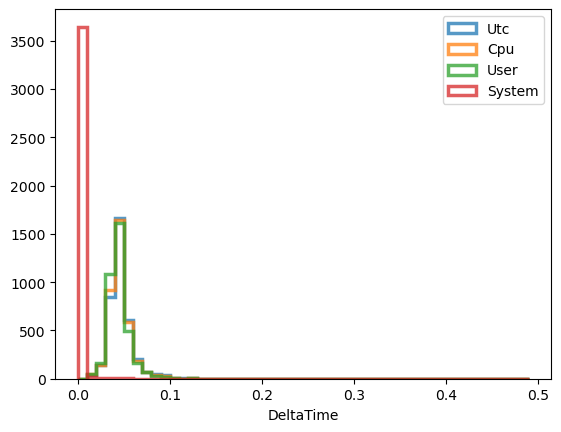

In [45]:
xbins = np.arange(0,.5, .01)
hist_config = {'bins': xbins, 'histtype': 'step', 'lw': 2.5, 'alpha': 0.75}
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeUtc_dt_secs'], 
         label='Utc', **hist_config)
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeCpuTime'],
         label='Cpu', **hist_config)
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeUserTime'],
         label='User', **hist_config)
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeSystemTime'],
         label='System', **hist_config)
plt.legend(loc='best')
plt.xlabel('DeltaTime')

In [46]:
metadata_df_2 = load_timings_from_logs(metadata_df_2, butler)

(array([1.180e+02, 4.300e+02, 2.049e+03, 7.430e+02, 2.240e+02, 6.700e+01,
        4.000e+01, 1.300e+01, 2.000e+00, 3.000e+00]),
 array([  2. ,  20.8,  39.6,  58.4,  77.2,  96. , 114.8, 133.6, 152.4,
        171.2, 190. ]),
 <BarContainer object of 10 artists>)

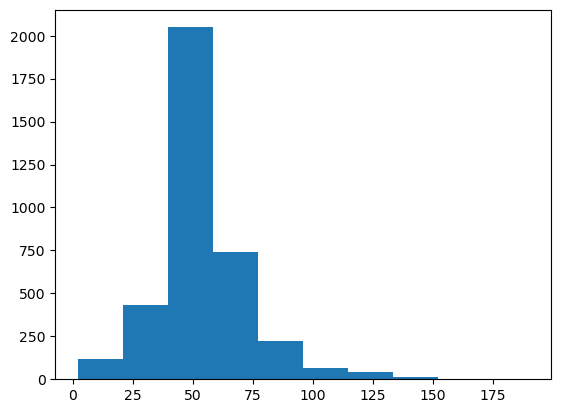

In [47]:
plt.hist(metadata_df_2['n_stamps_scored'])

Text(0, 0.5, 'Time (s)')

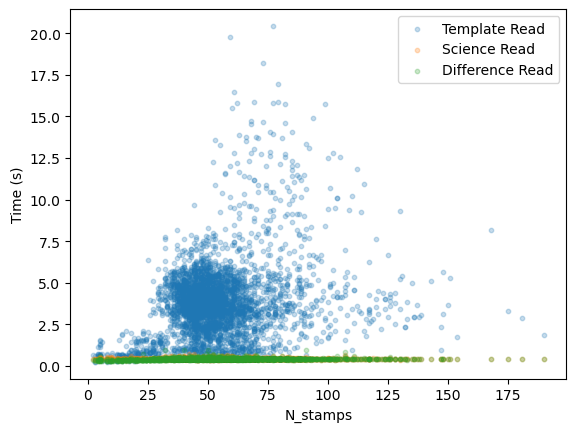

In [48]:
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['tmplt_read_timing'], s=10, alpha=0.25, label='Template Read')
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['science_read_timing'], s=10, alpha=0.25, label='Science Read')
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['diff_read_timing'], s=10, alpha=0.25, label='Difference Read')
# plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['computeReliability:computeReliability:deltaTimeSystemTime'], s=10, alpha=0.5, label='System')
# plt.ylim(0, 2)
# plt.gca().set_yscale('log')
plt.legend(loc='best')
plt.xlabel('N_stamps')
plt.ylabel('Time (s)')

Text(0, 0.5, 'Template Read Timing (s)')

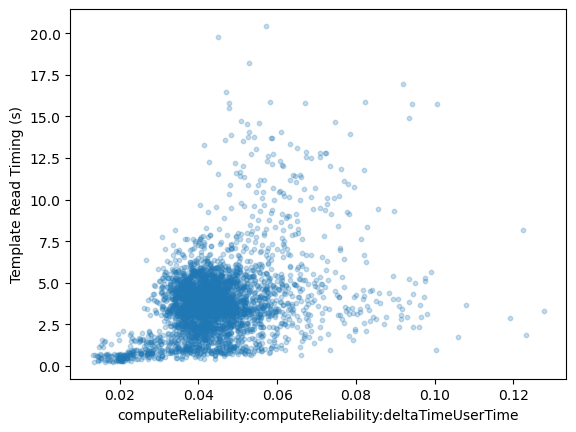

In [52]:
plt.scatter(metadata_df_2['computeReliability:computeReliability:deltaTimeUserTime'], 
            metadata_df_2['tmplt_read_timing'], s=10, alpha=0.25, label='Template Read')
plt.xlabel('computeReliability:computeReliability:deltaTimeUserTime')
plt.ylabel('Template Read Timing (s)')

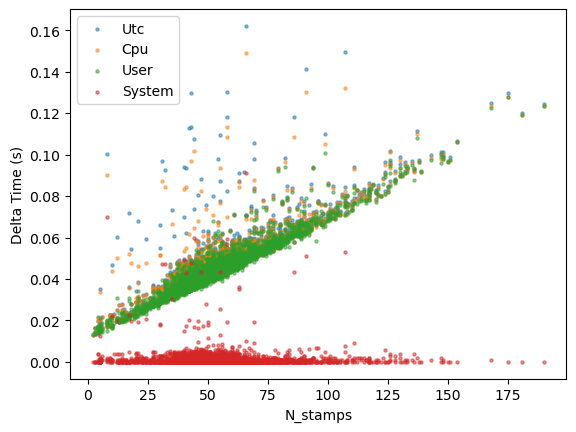

In [53]:
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['computeReliability:computeReliability:deltaTimeUtc_dt_secs'], s=5, alpha=0.5, label='Utc')
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['computeReliability:computeReliability:deltaTimeCpuTime'], s=5, alpha=0.5, label='Cpu')
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['computeReliability:computeReliability:deltaTimeUserTime'], s=5, alpha=0.5, label='User')
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['computeReliability:computeReliability:deltaTimeSystemTime'], s=5, alpha=0.5, label='System')
plt.xlabel('N_stamps')
plt.ylabel('Delta Time (s)')
plt.legend(loc='best')

Text(0.5, 0, 'DeltaTime/N_stamps')

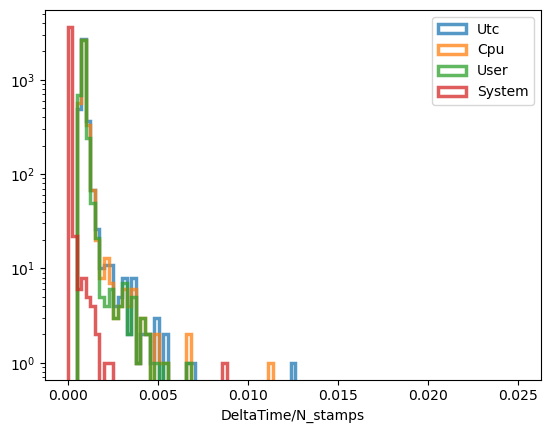

In [55]:
xbins = np.linspace(0, .025, 100)
hist2_config = {'bins': xbins, 'histtype': 'step', 'lw': 2.5, 'alpha': 0.75, 'log': True}
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeUtc_dt_secs']/metadata_df_2['n_stamps_scored'], 
         label='Utc', **hist2_config)
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeCpuTime']/metadata_df_2['n_stamps_scored'],
         label='Cpu', **hist2_config)
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeUserTime']/metadata_df_2['n_stamps_scored'],
         label='User', **hist2_config)
plt.hist(metadata_df_2['computeReliability:computeReliability:deltaTimeSystemTime']/metadata_df_2['n_stamps_scored'],
         label='System', **hist2_config)
plt.legend(loc='best')
plt.xlabel('DeltaTime/N_stamps')

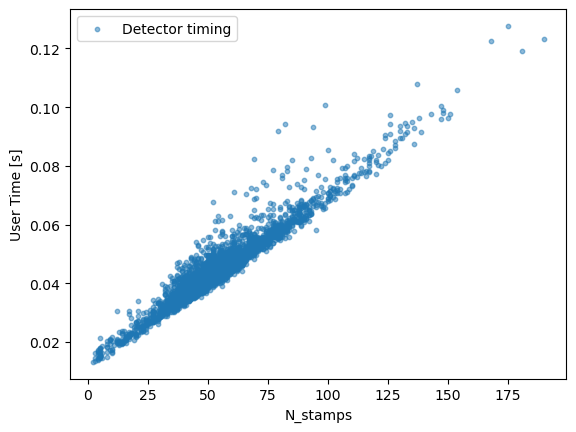

In [57]:
plt.scatter(metadata_df_2['n_stamps_scored'], metadata_df_2['computeReliability:computeReliability:deltaTimeUserTime'], s=10, alpha=0.5, label='Detector timing')
# plt.vlines(x=[64, 128], ymin=5, ymax=17, label='64 chunk')
plt.xlabel("N_stamps")
plt.ylabel("User Time [s]")
plt.legend(loc='best')

In [ ]:
""" mapping of visit to new visits
2026040220009 <--- original visit 2026012800087
2026040220010 <--- original visit 2026012800088
2026040220011 <--- original visit 2026012800089
2026040220012 <--- original visit 2026012800090
2026040220013 <--- original visit 2026012800091
2026040220014 <--- original visit 2026012800092
2026040220015 <--- original visit 2026012800097
2026040220016 <--- original visit 2026012800098
2026040220017 <--- original visit 2026012800099
2026040220018 <--- original visit 2026012800101
2026040220019 <--- original visit 2026012800102
2026040220020 <--- original visit 2026012800103
2026040220021 <--- original visit 2026012800104
"""

' mapping of visit to new visits\n2026020920015  <--- 2026012800087\n2026020920016  <--- 2026012800088\n2026020920017  <--- 2026012800089\n2026020920018  <--- 2026012800090\n2026020920019  <--- 2026012800091\n2026020920020  <--- 2026012800092\n2026020920021  <--- 2026012800097\n2026020920022  <--- 2026012800098\n2026020920023  <--- 2026012800099\n2026020920024  <--- 2026012800101\n2026020920025  <--- 2026012800102\n2026020920026  <--- 2026012800103\n2026020920027  <--- 2026012800104\n'

In [58]:
# define new column with the mapped visits
visit_mapping = {
    2026040220009: 2026012800087,
    2026040220010: 2026012800088,
    2026040220011: 2026012800089,
    2026040220012: 2026012800090,
    2026040220013: 2026012800091,
    2026040220014: 2026012800092,
    2026040220015: 2026012800097,
    2026040220016: 2026012800098,
    2026040220017: 2026012800099,
    2026040220018: 2026012800101,
    2026040220019: 2026012800102,
    2026040220020: 2026012800103,
    2026040220021: 2026012800104
}
metadata_df_2['mapped_visit'] = metadata_df_2['visit'].map(visit_mapping)

## Compare original runs vs PPDev

In [63]:
prompt_rerun = pd.merge(metadata_df_2, prompt_run, left_on=['mapped_visit', 'detector'], right_on=['visit', 'detector'], how='inner', suffixes=('_rerun', '_prompt'))

In [64]:
daytime_rerun = pd.merge(metadata_df_2, daytime_run, left_on=['mapped_visit', 'detector'], right_on=['visit', 'detector'], how='inner', suffixes=('_rerun', '_daytime'))

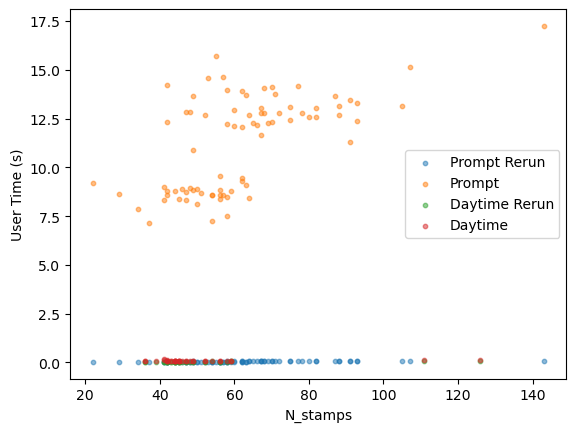

In [65]:
# scatter of user time vs n_stamps for the prompt rerun and daytime rerun, with different colors for the two runs
plt.scatter(prompt_rerun['n_stamps_scored_rerun'], prompt_rerun['computeReliability:computeReliability:deltaTimeUserTime_rerun'], s=10, alpha=0.5, label='Prompt Rerun')
plt.scatter(prompt_rerun['n_stamps_scored_rerun'], prompt_rerun['computeReliability:computeReliability:deltaTimeUserTime_prompt'], s=10, alpha=0.5, label='Prompt')
plt.scatter(daytime_rerun['n_stamps_scored_rerun'], daytime_rerun['computeReliability:computeReliability:deltaTimeUserTime_rerun'], s=10, alpha=0.5, label='Daytime Rerun')
plt.scatter(daytime_rerun['n_stamps_scored_rerun'], daytime_rerun['computeReliability:computeReliability:deltaTimeUserTime_daytime'], s=10, alpha=0.5, label='Daytime')
plt.xlabel('N_stamps')
plt.ylabel('User Time (s)')
plt.legend(loc='best')

In [66]:
metadata_df_2

,instrument,detector,visit,band,day_obs,physical_filter,computeReliability:computeReliability:__version__,computeReliability:computeReliability:nodeName,computeReliability:computeReliability:runStartUtc,computeReliability:computeReliability:runStartCpuTime,...,computeReliability:computeReliability:deltaTimeUtc_dt,computeReliability:computeReliability:deltaTimeUtc_dt_secs,computeReliability:computeReliability:deltaTimeCpuTime,computeReliability:computeReliability:deltaTimeUserTime,computeReliability:computeReliability:deltaTimeSystemTime,n_stamps_scored,tmplt_read_timing,science_read_timing,diff_read_timing,mapped_visit
0,LSSTCam,33,2026040220006,g,20260402,g_6,1,prompt-keda-lsstcam-wd6mv-zl2sl,2026-04-02T17:53:45.370844+00:00,112.149190,...,0 days 00:00:00.054035,0.054035,0.053604,0.051610,0.001994,58,3.1661,0.3969,0.3939,NaN
1,LSSTCam,29,2026040220003,g,20260402,g_6,1,prompt-keda-lsstcam-th9nn-zzwd7,2026-04-02T17:53:36.270218+00:00,168.977520,...,0 days 00:00:00.041953,0.041953,0.041712,0.038736,0.002978,33,4.3937,0.4339,0.4308,NaN
2,LSSTCam,114,2026040220004,g,20260402,g_6,1,prompt-keda-lsstcam-xvdwf-k9g4c,2026-04-02T17:53:41.629727+00:00,371.274517,...,0 days 00:00:00.041819,0.041819,0.041470,0.041471,0.000000,48,3.6726,0.4204,0.4133,NaN
3,LSSTCam,5,2026040220005,g,20260402,g_6,1,prompt-keda-lsstcam-qrcbd-cr6r5,2026-04-02T17:53:48.480247+00:00,172.380657,...,0 days 00:00:00.042595,0.042595,0.042236,0.039305,0.002929,47,4.5530,0.4055,0.4021,NaN
4,LSSTCam,179,2026040220001,g,20260402,g_6,1,prompt-keda-lsstcam-h4zl5-mlxlt,2026-04-02T17:47:40.893771+00:00,94.675250,...,0 days 00:00:00.023185,0.023185,0.022797,0.018827,0.003970,11,0.3248,0.3897,0.3103,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3684,LSSTCam,138,2026040220021,i,20260402,i_39,1,prompt-keda-lsstcam-cv5qz-kkdkz,2026-04-02T18:26:53.315321+00:00,1083.133027,...,0 days 00:00:00.066382,0.066382,0.065875,0.065876,0.000000,80,5.2045,0.4443,0.4317,2.026013e+12
3685,LSSTCam,187,2026040220021,i,20260402,i_39,1,prompt-keda-lsstcam-df8zv-t6z8d,2026-04-02T18:26:59.348886+00:00,1114.569834,...,0 days 00:00:00.093564,0.093564,0.092710,0.091543,0.001167,133,2.8043,0.4054,0.3772,2.026013e+12
3686,LSSTCam,46,2026040220021,i,20260402,i_39,1,prompt-keda-lsstcam-dhsm2-rfqn7,2026-04-02T18:26:58.848006+00:00,1225.269049,...,0 days 00:00:00.067679,0.067679,0.067086,0.067087,0.000000,91,5.1688,0.4255,0.4119,2.026013e+12
3687,LSSTCam,8,2026040220021,i,20260402,i_39,1,prompt-keda-lsstcam-c6r4w-lcxsj,2026-04-02T18:27:22.726256+00:00,1121.653821,...,0 days 00:00:00.149434,0.149434,0.131962,0.079179,0.052785,107,1.5818,0.6749,0.8599,2.026013e+12
